In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
warnings.filterwarnings("ignore", category=UserWarning, module ="openpyxl")

In [29]:
file_path = r"C:\Users\rajeshkumar.t\Desktop\ML\tranctions.csv"
df= pd.read_csv(file_path, low_memory =False)
df[df['transaction_dt']!='transaction_dt']
print(df.columns)

Index(['transaction_yr', 'transaction_mth', 'transaction_wk', 'transaction_dt',
       'transaction_status', 'transaction_source', 'live_response_code',
       'payment_instrument', 'bank_code', 'hyp_flag', 'asp_flag',
       'merchant_id', 'merchant_status', 'marketplace_id', 'pg_id',
       'flipkart_emi_flag', 'marketplace_context', 'is_shopsy_order',
       'emi_flag', 'adonc_flag', 'count_of_tx', 'acct_cnt', 'tot_amt',
       'tot_eff_amt_paymnt'],
      dtype='object')


In [30]:
df_status = df.copy()
df_status['transaction_dt'] = pd.to_datetime(df_status['transaction_dt'])
df_status['hour'] = df_status['transaction_dt'].dt.hour
df_status['dayofweek'] = df_status['transaction_dt'].dt.dayofweek
df_status['is_pending'] = df_status['transaction_status'].apply(lambda x:1 if x=='PENDING' else 0)


In [31]:
print(df_status['is_pending'].unique())

[0 1]


In [32]:
daily_stats = df_status.groupby(df_status['transaction_dt'].dt.date).agg({
    'count_of_tx': 'sum',
    'is_pending': 'sum',
}).reset_index()
daily_stats['pending_rate'] = (daily_stats['is_pending']/ daily_stats['count_of_tx'])* 100

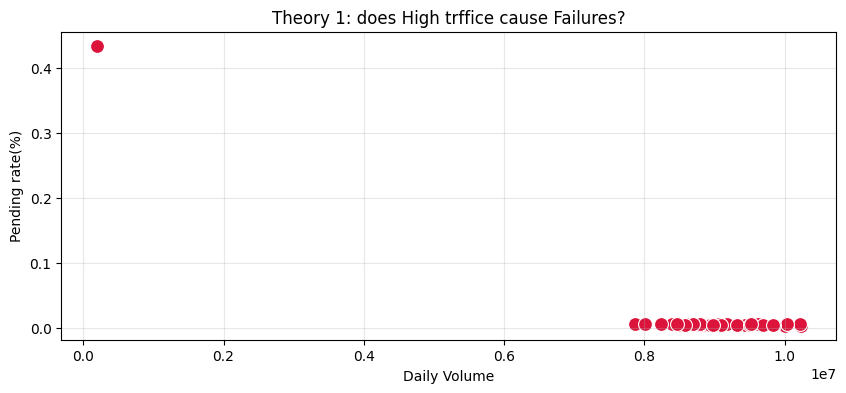

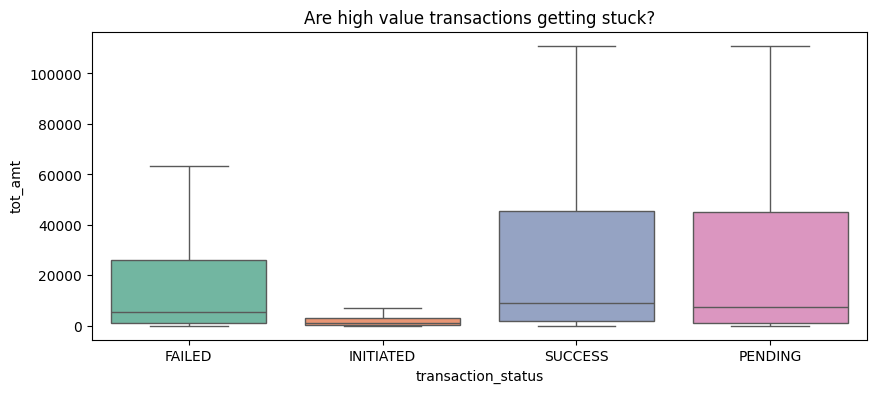

In [33]:
plt.figure(figsize=(10,4))
sns.scatterplot(data=daily_stats, x='count_of_tx', y='pending_rate', s=100, color= 'crimson')
plt.title('Theory 1: does High trffice cause Failures?')
plt.xlabel('Daily Volume')
plt.ylabel('Pending rate(%)')
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10,4))
sns.boxplot(data=df_status, x='transaction_status', y='tot_amt', 
            hue='transaction_status',
            legend=False, showfliers=False, palette='Set2')
plt.title('Are high value transactions getting stuck?')
plt.show()
           